# SignSpeech — Member 2: Hand Detection & ROI Pipeline

**Goal:** Take M1's frame loader and add per-frame MediaPipe hand detection.  
Crop the hand ROI from each frame, resize to 224×224, and deliver a  
`WLASLHandDataset` whose output shape is identical to M1's — `(T, 3, 224, 224)` —  
so M3 (CNN encoder) can swap in this dataset with **zero code changes**.

**Decisions baked in:**
- MediaPipe Hands (static image mode, `max_num_hands=1`, `min_detection_confidence=0.5`)
- Bounding box padded by 20% on each side to include wrist context
- Fallback: if detection fails on a frame, reuse the previous frame's crop (same as M1's frame-fail fallback)
- Ultimate fallback: if detection fails on the **first** frame, use centre-crop of the full frame
- Detection stats logged per clip so EDA can reveal problem classes

**Inputs from M1:**
- `outputs/splits.json` — train/val/test sample lists
- `outputs/label_map.json` — word ↔ integer label mapping
- `load_video_frames()` — copied from M1 (shared utility)

**Outputs delivered to team:**
- `train_loader`, `val_loader`, `test_loader` — same API as M1, now with hand crops
- `outputs/detection_stats.json` — per-clip detection rate for EDA
- EDA plots: detection rate distribution, fallback-frame count, sample crop grid

## Step 0 — Install & import libraries

In [1]:
# Install MediaPipe (pre-installed on Kaggle; this is a no-op if already present)
!pip install mediapipe --quiet

import os
import json
import random
import numpy as np
import cv2
import mediapipe as mp
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('All imports OK')
print(f'MediaPipe version : {mp.__version__}')
print(f'OpenCV  version   : {cv2.__version__}')
print(f'PyTorch version   : {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


2026-05-16 01:37:03.486773: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778895423.689774      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778895423.753489      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778895424.233267      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778895424.233308      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778895424.233311      57 computation_placer.cc:177] computation placer alr

All imports OK
MediaPipe version : 0.10.35
OpenCV  version   : 4.13.0
PyTorch version   : 2.10.0+cu128


## Step 1 — Configure paths & load M1 outputs

Point this to the same dataset root as M1.  
All M1 outputs (`splits.json`, `label_map.json`) live in `outputs/`.

In [2]:
# ── EDIT THESE TWO LINES ONLY ──────────────────────────────────────────────
KAGGLE     = True
LOCAL_ROOT = r'C:\path\to\your\dataset'
# ───────────────────────────────────────────────────────────────────────────

from pathlib import Path
import json

if KAGGLE:
    ROOT = Path('/kaggle/input/datasets/risangbaskoro/wlasl-processed')
    JSON_ROOT = Path('/kaggle/input/datasets/noureenzafan/json-files')
else:
    ROOT = Path(LOCAL_ROOT)
    JSON_ROOT = Path('outputs')

VIDEO_DIR  = ROOT / 'videos'
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Load JSON files ───────────────────────────────────────────────────────
with open(JSON_ROOT / 'splits.json', 'r') as f:
    splits = json.load(f)

train_samples = splits['train']
val_samples   = splits['val']
test_samples  = splits['test']

with open(JSON_ROOT / 'label_map.json', 'r') as f:
    label_map   = json.load(f)
    word_to_idx = label_map['word_to_idx']
    idx_to_word = {int(k): v for k, v in label_map['idx_to_word'].items()}

print(f'Splits loaded   →  train: {len(train_samples)}  val: {len(val_samples)}  test: {len(test_samples)}')
print(f'Label map       →  {len(word_to_idx)} classes')
print(f'Video dir       →  {VIDEO_DIR}  (exists: {VIDEO_DIR.exists()})')

Splits loaded   →  train: 748  val: 165  test: 100
Label map       →  100 classes
Video dir       →  /kaggle/input/datasets/risangbaskoro/wlasl-processed/videos  (exists: True)


## Step 2 — Copy M1's frame loader (shared utility)

M2 reuses `load_video_frames()` exactly as M1 defined it.  
In a real project this would live in a shared `utils.py`; here we copy it  
so the notebook is fully self-contained.

In [ ]:
NUM_FRAMES = 32
FRAME_SIZE = 224


def load_video_frames(
    video_path: str,
    frame_start: int,
    frame_end: int,
    num_frames: int = NUM_FRAMES,
    frame_size: int = FRAME_SIZE,
) -> np.ndarray | None:
    """
    Load T uniformly-sampled frames from a video clip.
    Returns numpy array of shape (T, 3, H, W), float32 in [0, 1],
    or None if the video cannot be opened.  (Copied verbatim from M1.)
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    start = max(0, frame_start - 1)
    end   = total_frames - 1 if frame_end == -1 else min(frame_end - 1, total_frames - 1)
    if start >= end:
        start, end = 0, total_frames - 1

    indices = np.linspace(start, end, num_frames, dtype=int)
    frames  = []
#   Read Frames
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret or frame is None:
            frames.append(frames[-1].copy() if frames else
                          np.zeros((frame_size, frame_size, 3), dtype=np.uint8))
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (frame_size, frame_size),
                           interpolation=cv2.INTER_LINEAR)
        frames.append(frame)

    cap.release()
    # Convert to NumPy + Normalize
    clip = np.stack(frames, axis=0).astype(np.float32) / 255.0  # (T, H, W, 3)
    clip = np.transpose(clip, (0, 3, 1, 2))                      # (T, 3, H, W) for PyTorch
    return clip


print('load_video_frames() ready')

load_video_frames() ready


## Step 3 — MediaPipe hand detector & ROI cropper

**How it works:**
1. Run MediaPipe Hands on a single RGB frame (static image mode = no temporal smoothing,  
   which is correct here since we are sampling non-consecutive frames).
2. If a hand is detected, take the bounding box of all 21 landmarks.
3. Pad the bounding box by `PAD_RATIO` on each side (default 20%) so the  
   crop includes wrist context — important for distinguishing similar signs.
4. Clamp the padded box to image edges, then crop & resize to 224×224.
5. If **no hand detected**, return `None` → caller applies the fallback logic.

**Why static image mode?**  
We pass frames individually, not a continuous video stream, so we don't  
want MediaPipe's temporal smoothing to carry over wrong detections.

In [ ]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# ── Download hand landmarker model (run once) ───────────────────────────
MODEL_PATH = "hand_landmarker.task"

if not Path(MODEL_PATH).exists():
    !wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

# ── Hyper-parameters ─────────────────────────────────────────────────────
PAD_RATIO = 0.20
MAX_HANDS = 1
FRAME_SIZE = 224

# ── Create detector ──────────────────────────────────────────────────────
base_options = python.BaseOptions(model_asset_path=MODEL_PATH)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=MAX_HANDS,
)

detector = vision.HandLandmarker.create_from_options(options)

# ── Hand crop function ───────────────────────────────────────────────────
def get_hand_crop(
    frame_rgb: np.ndarray,
    detector,
    pad_ratio: float = PAD_RATIO,
    out_size: int = FRAME_SIZE,
):

    h, w = frame_rgb.shape[:2]

    # Convert numpy image to MediaPipe image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    # Detect hands
    detection_result = detector.detect(mp_image)

    if len(detection_result.hand_landmarks) == 0:
        return None, None

    # First detected hand
    landmarks = detection_result.hand_landmarks[0]

    # Convert normalized coords → pixels
    xs = [lm.x * w for lm in landmarks]
    ys = [lm.y * h for lm in landmarks]

    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    # Padding
    bw = x_max - x_min
    bh = y_max - y_min

    pad_x = bw * pad_ratio
    pad_y = bh * pad_ratio

    x1 = max(0, int(x_min - pad_x))
    y1 = max(0, int(y_min - pad_y))
    x2 = min(w, int(x_max + pad_x))
    y2 = min(h, int(y_max + pad_y))

    # Guard
    if x2 <= x1 or y2 <= y1:
        return None, None
    
    crop = frame_rgb[y1:y2, x1:x2]

    crop = cv2.resize(
        crop,
        (out_size, out_size),
        interpolation=cv2.INTER_LINEAR
    )

    return crop, (x1, y1, x2, y2)

# ── Smoke test ───────────────────────────────────────────────────────────
dummy = np.zeros((480, 640, 3), dtype=np.uint8)

crop, bbox = get_hand_crop(dummy, detector)

print(f'Smoke test → crop: {crop}  bbox: {bbox}')
print('(None expected for blank image)')

print('\nget_hand_crop() ready')

Smoke test → crop: None  bbox: None
(None expected for blank image)

get_hand_crop() ready


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778895461.246080     142 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778895461.266055     144 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778895461.286703     141 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


## Step 4 — Per-clip hand extraction with fallback logic

This function wraps `load_video_frames()` and `get_hand_crop()` into  
a single pipeline that returns a clip of shape `(T, 3, 224, 224)` — identical  
to M1 — but with each frame replaced by its hand ROI crop.

**Fallback hierarchy:**
1. ✅ Hand detected → use cropped & resized ROI
2. ⚠️ No hand on this frame, but previous frame had one → reuse last good crop
3. ⚠️ No hand on first frame → use centre-crop of the full 224×224 frame
4. ❌ Video failed to load → return zero tensor (same as M1)

In [7]:
def load_hand_clip(
    video_path:  str,
    frame_start: int,
    frame_end:   int,
    num_frames:  int   = NUM_FRAMES,
    frame_size:  int   = FRAME_SIZE,
    pad_ratio:   float = PAD_RATIO,
) -> tuple:
    """
    Load a T-frame clip with per-frame hand ROI cropping and fallback logic.

    Uses the same MediaPipe Tasks detector created in Step 3 (no legacy API).

    Returns:
        clip  : float32 numpy array of shape (T, 3, H, W), values in [0, 1]
        stats : dict with detection diagnostics for EDA
                  {
                    'detected'  : int,   # frames where a hand was found
                    'fallback'  : int,   # frames using the previous crop
                    'centre'    : int,   # frames using the centre-crop fallback
                    'total'     : int,   # = num_frames
                    'det_rate'  : float, # detected / total
                    'video_ok'  : bool,  # False if video failed to open
                  }
    """
    empty_stats = dict(detected=0, fallback=0, centre=0,
                       total=num_frames, det_rate=0.0, video_ok=False)

    # --- Step A: load raw frames via M1 utility ---
    raw_clip = load_video_frames(video_path, frame_start, frame_end,
                                 num_frames, frame_size)

    if raw_clip is None:
        zeros = np.zeros((num_frames, 3, frame_size, frame_size), dtype=np.float32)
        return zeros, empty_stats

    # raw_clip is (T, 3, H, W) float32 [0,1]
    # Convert to (T, H, W, 3) uint8 for MediaPipe
    raw_hwc = (np.transpose(raw_clip, (0, 2, 3, 1)) * 255).astype(np.uint8)

    # --- Step B: per-frame hand detection using Tasks API detector ---
    hand_frames = []
    last_good_crop = None
    n_detected = 0
    n_fallback  = 0
    n_centre    = 0

    for frame_uint8 in raw_hwc:   # frame_uint8: (H, W, 3) uint8 RGB
        # get_hand_crop uses the global `detector` from Step 3 (Tasks API)
        crop, bbox = get_hand_crop(frame_uint8, detector,
                                   pad_ratio=pad_ratio,
                                   out_size=frame_size)

        if crop is not None:
            # Hand detected successfully
            hand_frames.append(crop)
            last_good_crop = crop
            n_detected += 1

        elif last_good_crop is not None:
            # No hand — reuse previous frame's crop
            hand_frames.append(last_good_crop.copy())
            n_fallback += 1

        else:
            # First frame(s) missed — use the full frame as-is (centre fallback)
            hand_frames.append(frame_uint8.copy())
            n_centre += 1

    # --- Step C: stack → (T, H, W, 3), normalise → [0,1], transpose → (T, 3, H, W) ---
    clip = np.stack(hand_frames, axis=0).astype(np.float32) / 255.0  # (T, H, W, 3)
    clip = np.transpose(clip, (0, 3, 1, 2))                           # (T, 3, H, W)

    stats = dict(
        detected = n_detected,
        fallback = n_fallback,
        centre   = n_centre,
        total    = num_frames,
        det_rate = n_detected / num_frames,
        video_ok = True,
    )

    return clip, stats


print('load_hand_clip() ready — uses Tasks API detector from Step 3')


load_hand_clip() ready — uses Tasks API detector from Step 3


## Step 5 — Smoke test on one video

Run `load_hand_clip()` on the first training sample and verify:
- Output shape `(32, 3, 224, 224)` ← same as M1
- Value range `[0, 1]`
- Detection stats make sense

In [8]:
sample = train_samples[0]

clip, stats = load_hand_clip(
    sample['video_path'],
    sample['frame_start'],
    sample['frame_end'],
)

print('── Smoke test ──────────────────────────────────')
print(f'Clip shape   : {clip.shape}   ← expected (32, 3, 224, 224)')
print(f'Value range  : [{clip.min():.3f}, {clip.max():.3f}]  ← expected [0, 1]')
print(f'dtype        : {clip.dtype}   ← expected float32')
print(f'Gloss        : {sample["gloss"]}  |  label : {sample["label"]}')
print()
print('── Detection stats ─────────────────────────────')
for k, v in stats.items():
    print(f'  {k:<12} : {v}')

── Smoke test ──────────────────────────────────
Clip shape   : (32, 3, 224, 224)   ← expected (32, 3, 224, 224)
Value range  : [0.000, 1.000]  ← expected [0, 1]
dtype        : float32   ← expected float32
Gloss        : city  |  label : 20

── Detection stats ─────────────────────────────
  detected     : 10
  fallback     : 16
  centre       : 6
  total        : 32
  det_rate     : 0.3125
  video_ok     : True


## Step 6 — PyTorch Dataset & DataLoaders

`WLASLHandDataset` is a drop-in replacement for M1's `WLASLDataset`.  
M3 only ever calls `DataLoader(dataset, ...)` — nothing else changes.

In [9]:
class WLASLHandDataset(Dataset):
    """
    PyTorch Dataset for WLASL with per-frame MediaPipe hand-crop preprocessing.

    Drop-in replacement for M1's WLASLDataset — identical __getitem__ signature:
        frames : FloatTensor (T, 3, 224, 224)  — hand-cropped frames, [0, 1]
        label  : LongTensor scalar             — integer class index

    Additional attribute `detection_log` collects per-sample stats so
    EDA can identify hard classes and inform M2's validation work.
    """

    def __init__(
        self,
        samples:    list,
        num_frames: int   = NUM_FRAMES,
        frame_size: int   = FRAME_SIZE,
        pad_ratio:  float = PAD_RATIO,
        log_stats:  bool  = False,   # set True during EDA; adds overhead
    ):
        self.samples    = samples
        self.num_frames = num_frames
        self.frame_size = frame_size
        self.pad_ratio  = pad_ratio
        self.log_stats  = log_stats
        self.detection_log = []   # filled only when log_stats=True

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        sample = self.samples[idx]

        clip, stats = load_hand_clip(
            sample['video_path'],
            sample['frame_start'],
            sample['frame_end'],
            self.num_frames,
            self.frame_size,
            self.pad_ratio,
        )

        if self.log_stats:
            self.detection_log.append({
                'video_id' : sample['video_id'],
                'gloss'    : sample['gloss'],
                'label'    : sample['label'],
                **stats,
            })

        frames_tensor = torch.from_numpy(clip)
        label_tensor  = torch.tensor(sample['label'], dtype=torch.long)

        return frames_tensor, label_tensor


# ── Instantiate datasets ──────────────────────────────────────────────────
train_dataset = WLASLHandDataset(train_samples)
val_dataset   = WLASLHandDataset(val_samples)
test_dataset  = WLASLHandDataset(test_samples)

print(f'Dataset sizes  →  train: {len(train_dataset)}  val: {len(val_dataset)}  test: {len(test_dataset)}')

# Quick item check
frames, label = train_dataset[0]
print(f'Single item    →  frames: {frames.shape}  |  label: {label.item()} ({idx_to_word[label.item()]})')

Dataset sizes  →  train: 748  val: 165  test: 100
Single item    →  frames: torch.Size([32, 3, 224, 224])  |  label: 20 (city)


In [13]:
BATCH_SIZE  = 8
NUM_WORKERS = 0   # set to 0 on Windows if you get multiprocessing errors

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = False,
    drop_last   = True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 0,
    pin_memory  = False,
)

print(f'Batches per epoch  →  train: {len(train_loader)}  |  val: {len(val_loader)}  |  test: {len(test_loader)}')

# ── Batch shape verification ──────────────────────────────────────────────
batch_frames, batch_labels = next(iter(train_loader))
print(f'\nBatch shape check:')
print(f'  frames : {batch_frames.shape}   ← expected ({BATCH_SIZE}, 32, 3, 224, 224)')
print(f'  labels : {batch_labels.shape}    ← expected ({BATCH_SIZE},)')
print(f'  values : [{batch_frames.min():.3f}, {batch_frames.max():.3f}]')
print(f'  glosses: {[idx_to_word[l.item()] for l in batch_labels]}')

Batches per epoch  →  train: 93  |  val: 21  |  test: 13

Batch shape check:
  frames : torch.Size([8, 32, 3, 224, 224])   ← expected (8, 32, 3, 224, 224)
  labels : torch.Size([8])    ← expected (8,)
  values : [0.000, 1.000]
  glosses: ['apple', 'fine', 'before', 'clothes', 'give', 'like', 'computer', 'go']


## Step 7 — EDA: detection rate across a sample of training clips

We run `load_hand_clip()` with `log_stats=True` on a random sample of  
**150 training videos** to map out where detection is strong vs. weak.  
This answers three questions:
1. What fraction of clips have good detection (≥ 80% frames detected)?
2. How often does the fallback chain kick in?
3. Are there specific word classes where detection fails consistently?

In [14]:
EDA_SAMPLE_SIZE = 150   # increase if you have time; 150 balances speed vs. coverage

eda_samples = random.sample(train_samples, min(EDA_SAMPLE_SIZE, len(train_samples)))
eda_log     = []

print(f'Running hand detection on {len(eda_samples)} training clips…')
print('(This takes ~1–2 minutes on CPU — MediaPipe is fast but not instant)')

for i, s in enumerate(eda_samples):
    _, stats = load_hand_clip(
        s['video_path'], s['frame_start'], s['frame_end']
    )
    eda_log.append({'gloss': s['gloss'], 'label': s['label'], **stats})

    if (i + 1) % 30 == 0:
        print(f'  {i+1}/{len(eda_samples)} done')

print('Done!')

# Save detection stats for the full team
with open(OUTPUT_DIR / 'detection_stats.json', 'w') as f:
    json.dump(eda_log, f, indent=2)
print(f'Saved → {OUTPUT_DIR}/detection_stats.json')

Running hand detection on 150 training clips…
(This takes ~1–2 minutes on CPU — MediaPipe is fast but not instant)
  30/150 done
  60/150 done
  90/150 done
  120/150 done
  150/150 done
Done!
Saved → outputs/detection_stats.json


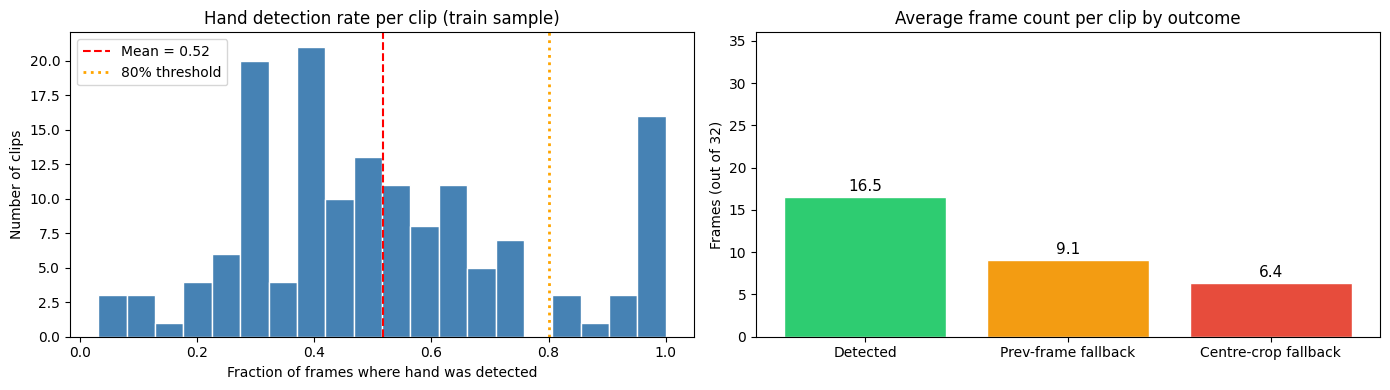

Detection summary (n=150 valid clips):
  Mean detection rate  : 0.52
  Clips ≥80% detected  : 23 (15.3%)
  Videos failed to open: 0


In [15]:
# ── 7a. Detection rate distribution ──────────────────────────────────────
det_rates  = [e['det_rate']  for e in eda_log if e['video_ok']]
n_fallback = [e['fallback']  for e in eda_log if e['video_ok']]
n_centre   = [e['centre']    for e in eda_log if e['video_ok']]
n_failed   = sum(1 for e in eda_log if not e['video_ok'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: histogram of per-clip detection rates
axes[0].hist(det_rates, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(det_rates), color='red', linestyle='--',
                label=f'Mean = {np.mean(det_rates):.2f}')
axes[0].axvline(0.80, color='orange', linestyle=':', linewidth=2,
                label='80% threshold')
axes[0].set_title('Hand detection rate per clip (train sample)')
axes[0].set_xlabel('Fraction of frames where hand was detected')
axes[0].set_ylabel('Number of clips')
axes[0].legend()

# Right: stacked bar of frame outcomes averaged across all clips
avg_detected  = np.mean([e['detected']  for e in eda_log if e['video_ok']])
avg_fallback  = np.mean(n_fallback)
avg_centre    = np.mean(n_centre)

categories = ['Detected', 'Prev-frame fallback', 'Centre-crop fallback']
values     = [avg_detected, avg_fallback, avg_centre]
colors     = ['#2ecc71', '#f39c12', '#e74c3c']

bars = axes[1].bar(categories, values, color=colors, edgecolor='white')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Average frame count per clip by outcome')
axes[1].set_ylabel(f'Frames (out of {NUM_FRAMES})')
axes[1].set_ylim(0, NUM_FRAMES + 4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'detection_rate_distribution.png', dpi=120)
plt.show()

good_clips = sum(1 for r in det_rates if r >= 0.80)
print(f'Detection summary (n={len(det_rates)} valid clips):')
print(f'  Mean detection rate  : {np.mean(det_rates):.2f}')
print(f'  Clips ≥80% detected  : {good_clips} ({100*good_clips/len(det_rates):.1f}%)')
print(f'  Videos failed to open: {n_failed}')

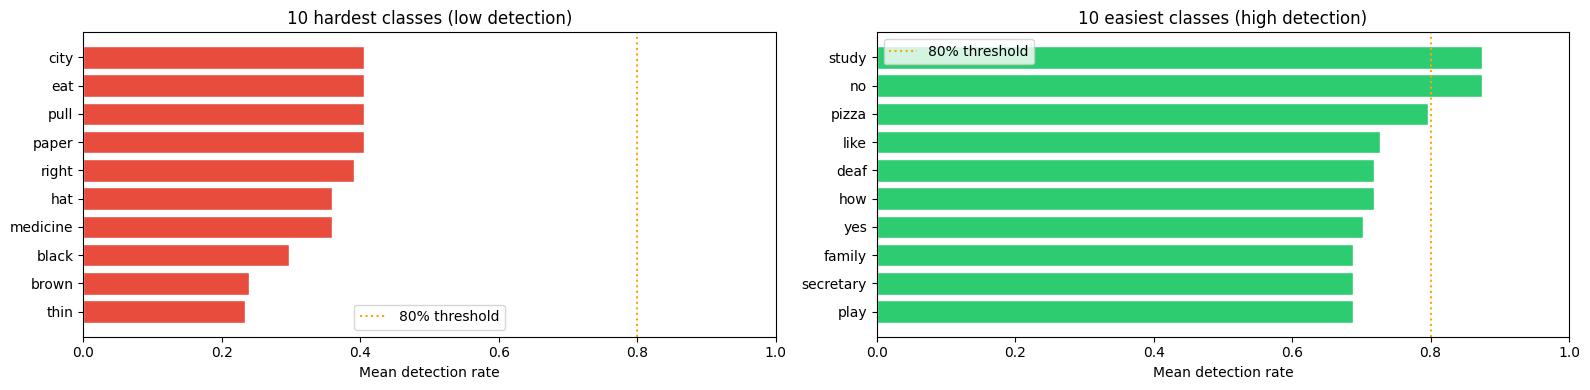

In [16]:
# ── 7b. Per-class detection rate — find the hardest sign classes ──────────
from collections import defaultdict

class_rates = defaultdict(list)
for e in eda_log:
    if e['video_ok']:
        class_rates[e['gloss']].append(e['det_rate'])

# Classes with at least 2 samples in the EDA set
class_mean = {
    gloss: np.mean(rates)
    for gloss, rates in class_rates.items()
    if len(rates) >= 2
}

if class_mean:
    sorted_classes = sorted(class_mean.items(), key=lambda x: x[1])
    worst_10  = sorted_classes[:10]
    best_10   = sorted_classes[-10:]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    for ax, data, title, color in [
        (axes[0], worst_10,  '10 hardest classes (low detection)', '#e74c3c'),
        (axes[1], best_10,   '10 easiest classes (high detection)', '#2ecc71'),
    ]:
        classes, rates = zip(*data)
        ax.barh(classes, rates, color=color, edgecolor='white')
        ax.set_xlim(0, 1)
        ax.axvline(0.80, color='orange', linestyle=':', label='80% threshold')
        ax.set_title(title)
        ax.set_xlabel('Mean detection rate')
        ax.legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'per_class_detection.png', dpi=120)
    plt.show()
else:
    print('Not enough per-class samples in the EDA set — increase EDA_SAMPLE_SIZE.')

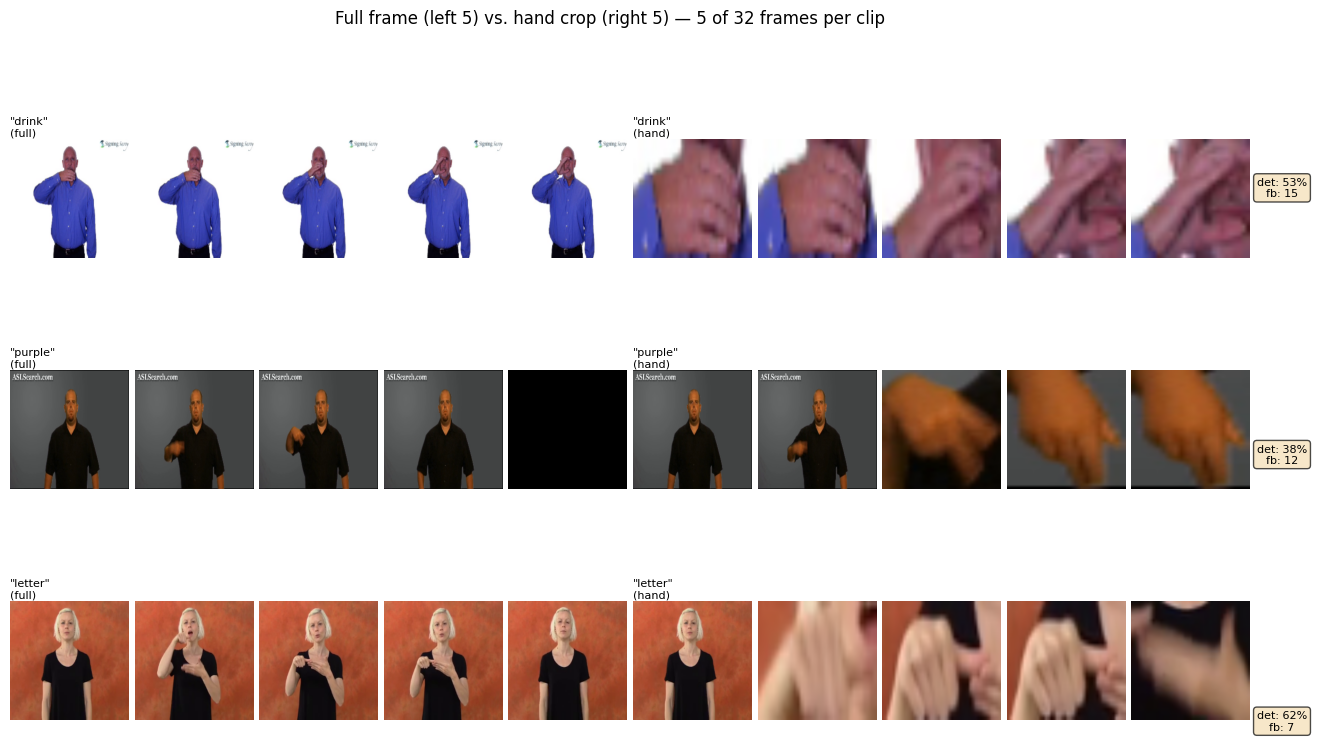

Visual comparison saved.


In [17]:
# ── 7c. Visual: side-by-side full frame vs. hand crop for 3 words ─────────
words_to_show = random.sample(list(set(s['gloss'] for s in train_samples)), 3)

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(3, 10, figure=fig, hspace=0.5, wspace=0.05)

for row, word in enumerate(words_to_show):
    word_samples = [s for s in train_samples if s['gloss'] == word]
    if not word_samples:
        continue
    s = word_samples[0]

    # Full-frame clip from M1
    raw_clip = load_video_frames(s['video_path'], s['frame_start'], s['frame_end'])
    # Hand-crop clip from M2
    hand_clip, stats = load_hand_clip(s['video_path'], s['frame_start'], s['frame_end'])

    if raw_clip is None:
        continue

    # Show 5 evenly-spaced frames from each
    frame_indices = np.linspace(0, NUM_FRAMES - 1, 5, dtype=int)

    for col_offset, clip, clip_label in [
        (0, raw_clip,  'full'),
        (5, hand_clip, 'hand'),
    ]:
        for i, fi in enumerate(frame_indices):
            ax = fig.add_subplot(gs[row, col_offset + i])
            img = np.transpose(clip[fi], (1, 2, 0))
            ax.imshow(img)
            ax.axis('off')
            if i == 0:
                ax.set_title(f'"{word}"\n({clip_label})', fontsize=8, loc='left', pad=2)

    # Annotate detection rate
    fig.text(
        0.92, (2 - row) / 3 + 0.13,
        f'det: {stats["det_rate"]:.0%}\nfb: {stats["fallback"]}',
        fontsize=8, va='center', ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7)
    )

plt.suptitle('Full frame (left 5) vs. hand crop (right 5) — 5 of 32 frames per clip', y=1.02)
plt.savefig(OUTPUT_DIR / 'hand_crop_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Visual comparison saved.')

## Step 8 — Validate detection across diverse signers

WLASL has multiple signers per word. A model that only works for one  
signer's hand size / skin tone is not generalising. Here we check  
whether detection rate varies across signers for the same words.

In [18]:
# Pick up to 5 words that have ≥3 training samples and test detection on each instance
from collections import Counter

gloss_counts = Counter(s['gloss'] for s in train_samples)
multi_signer_words = [g for g, c in gloss_counts.items() if c >= 3][:5]

print(f'Checking signer diversity for: {multi_signer_words}')

signer_results = defaultdict(list)   # gloss → list of (video_id, det_rate)

for word in multi_signer_words:
    word_samples = [s for s in train_samples if s['gloss'] == word][:5]  # cap at 5
    for s in word_samples:
        _, stats = load_hand_clip(s['video_path'], s['frame_start'], s['frame_end'])
        signer_results[word].append((s['video_id'], stats['det_rate']))

print()
print(f'{"Gloss":<20} {"Video ID":<12} {"Det rate":>10}')
print('-' * 46)
for word, entries in signer_results.items():
    for vid_id, rate in entries:
        flag = '⚠️ ' if rate < 0.5 else '✓  '
        print(f'{word:<20} {vid_id:<12} {rate:>9.0%}  {flag}')
    rates = [r for _, r in entries]
    print(f'{"  → spread:":<20} {"min":<12} {min(rates):.0%} / max {max(rates):.0%}')
    print()

Checking signer diversity for: ['city', 'shirt', 'who', 'but', 'play']

Gloss                Video ID       Det rate
----------------------------------------------
city                 10893              31%  ⚠️ 
city                 10892              69%  ✓  
city                 10895              41%  ⚠️ 
city                 10894              72%  ✓  
city                 65363              12%  ⚠️ 
  → spread:          min          12% / max 72%

shirt                51064             100%  ✓  
shirt                51061              78%  ✓  
shirt                51060              66%  ✓  
shirt                51063             100%  ✓  
shirt                51056              44%  ⚠️ 
  → spread:          min          44% / max 100%

who                  66779              38%  ⚠️ 
who                  66778               6%  ⚠️ 
who                  63242              22%  ⚠️ 
who                  63227              59%  ✓  
who                  63225              19%  ⚠️ 
  

## Step 9 — Summary & handoff to M3

Copy these lines at the top of M3's notebook to use the hand-crop DataLoaders:

In [19]:
# ── List all delivered outputs ────────────────────────────────────────────
delivered = [
    'detection_stats.json',
    'detection_rate_distribution.png',
    'per_class_detection.png',
    'hand_crop_comparison.png',
]

print('Files delivered to team:')
for fname in delivered:
    fpath  = OUTPUT_DIR / fname
    status = '✓' if fpath.exists() else '✗ NOT FOUND'
    print(f'  {status}  outputs/{fname}')

print()
print('──────────────────────────────────────────────────────────────')
print('M3 IMPORT SNIPPET  (copy to top of M3 notebook)')
print('──────────────────────────────────────────────────────────────')
print('''
import json, torch
from torch.utils.data import DataLoader

# ── Paste the WLASLHandDataset class and load_hand_clip() here ──
# (or import from a shared utils.py)

with open('outputs/label_map.json') as f:
    lm = json.load(f)
    word_to_idx = lm['word_to_idx']
    idx_to_word = {int(k): v for k, v in lm['idx_to_word'].items()}

with open('outputs/splits.json') as f:
    splits = json.load(f)

train_loader = DataLoader(WLASLHandDataset(splits['train']), batch_size=8, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(WLASLHandDataset(splits['val']),   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# Each batch: frames (8, 32, 3, 224, 224) float32 [0,1]  |  labels (8,) int64
''')

Files delivered to team:
  ✓  outputs/detection_stats.json
  ✓  outputs/detection_rate_distribution.png
  ✓  outputs/per_class_detection.png
  ✓  outputs/hand_crop_comparison.png

──────────────────────────────────────────────────────────────
M3 IMPORT SNIPPET  (copy to top of M3 notebook)
──────────────────────────────────────────────────────────────

import json, torch
from torch.utils.data import DataLoader

# ── Paste the WLASLHandDataset class and load_hand_clip() here ──
# (or import from a shared utils.py)

with open('outputs/label_map.json') as f:
    lm = json.load(f)
    word_to_idx = lm['word_to_idx']
    idx_to_word = {int(k): v for k, v in lm['idx_to_word'].items()}

with open('outputs/splits.json') as f:
    splits = json.load(f)

train_loader = DataLoader(WLASLHandDataset(splits['train']), batch_size=8, shuffle=True,  num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(WLASLHandDataset(splits['val']),   batch_size=8, shuffle=False, num_workers=2, pi